### MAI GIA BẢO
### 24520153

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
df = sns.load_dataset("iris")        # hoac: from sklearn.datasets import load_iris
print(df.head())
print(df.shape)
print(df.dtypes)
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### 1.1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [3]:
# 1. năm dòng đầu
print("5 dòng đầu:")
print(df.head())

# 2. số dòng, số cột
print("\nSố dòng, số cột:", df.shape)

# 3. kiểu dữ liệu từng cột
print("\nKiểu dữ liệu từng cột:")
print(df.dtypes)

5 dòng đầu:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Số dòng, số cột: (150, 5)

Kiểu dữ liệu từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


**Nhận xét 1.1:** Bộ Iris có **150 dòng, 5 cột**, 4 cột kiểu `float64` và 1 cột `species` kiểu `category` gồm 3 loài (*setosa*, *versicolor*, *virginica*), mỗi loài 50 mẫu.

### 1.2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

In [4]:
rows = {}
for col in numeric_cols:
    s = df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    rows[col] = {
        "mean": s.mean(),
        "median": s.median(),
        "mode": s.mode().iloc[0],
        "var": s.var(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
    }

stats_table = pd.DataFrame(rows).T.round(3)
stats_table

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843,5.80,5.0,0.686,0.828,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057,3.00,3.0,0.190,0.436,2.0,4.4,2.8,3.3,0.5
petal_length,3.758,4.35,1.4,3.116,1.765,1.0,6.9,1.6,5.1,3.5
petal_width,1.199,1.30,0.2,0.581,0.762,0.1,2.5,0.3,1.8,1.5


**Nhận xét 1.2:** `petal_length` và `petal_width` có **var/std lớn và IQR rộng** nhất nên hai cột này phân tán các giá trị rất rộng do khác biệt giữa các loài (giá trị ít phân tán thì các loại ít khác biệt nhau). `sepal_width` gọn nhất (IQR = 0.5 tức là 50% dữ liệu của cột `sepal_with` dao động quanh 2.8 -> 3.3).

### 1.3. Thống kê theo nhóm loài (groupby species)

In [15]:
# mean và std của từng cột theo từng loài
group_stats = df.groupby("species", observed=True)[numeric_cols].agg(["mean", "std"]).round(3)
group_stats

sepal_length        sepal_width        petal_length         \
                   mean    std        mean    std         mean    std   
species                                                                 
setosa            5.006  0.352       3.428  0.379        1.462  0.174   
versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
virginica         6.588  0.636       2.974  0.322        5.552  0.552   

           petal_width         
                  mean    std  
species                        
setosa           0.246  0.105  
versicolor       1.326  0.198  
virginica        2.026  0.275

**Nhận xét 1.3:** Loài **setosa** khác nhất với `petal_length` trung bình ~1.46 và `petal_width` ~0.25, nhỏ hơn hẳn versicolor (~4.26 / 1.33) và virginica (~5.55 / 2.03). 
- Hai biến `petal` là dấu hiệu phân biệt loài mạnh nhất ( ví dụ: Setosa có petal_lenghth trung là 1.462 cm và độ lệch chuẩn 0.174 cm còn 2 loài kia đều như vậy với độ lệch chuẩn (std) thấp => một bông hoa có petal_length khoản 1.423 cm thì có thể dự đoán nó là thuộc loài setosa)

- Hai biến `sepal` chồng lấn nhiều hơn. ví dụ: Versicolor (sepal_width = 2.77) và Virginica (2.97) gần bằng nhau. Hơn nữa, vì có độ lệch chuẩn (std ~ 0.516 và 0.636), một bông hoa Versicolor hơi to sẽ giống một bông hoa Virginica hơi nhỏ.

## Phần 2. Phân phối xác suất

### 2.1. Histogram + KDE cho từng biến

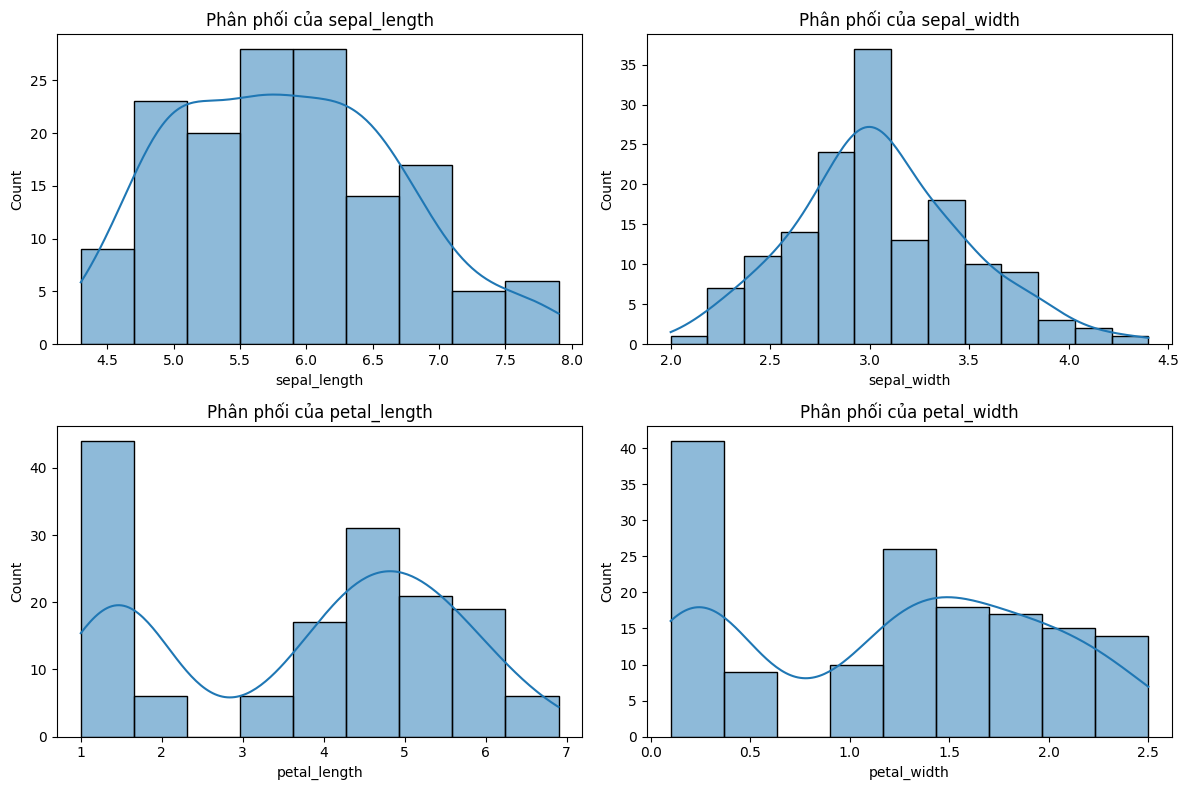

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="tab:blue")
    ax.set_title(f"Phân phối của {col}")
plt.tight_layout()
plt.show()

**Nhận xét 2.1:**
- `sepal_length`, `sepal_width`: đường cong (đường KDE) chỉ tạo ra một đỉnh duy nhất (`sepal_width cân đối nhất vì giống mấy cái ảnh ví dụ phân phối chuẩn).

- `petal_length`, `petal_width`: **đường KDE tạo ra hai đỉnh**, cụm nhỏ tách hẳn bên trái là *setosa*, cụm lớn bên phải là *versicolor* + *virginica*. Đây là lý do 2 biến petal tách loài tốt (xem mục 1.3).

### 2.2. Boxplot từng biến theo loài

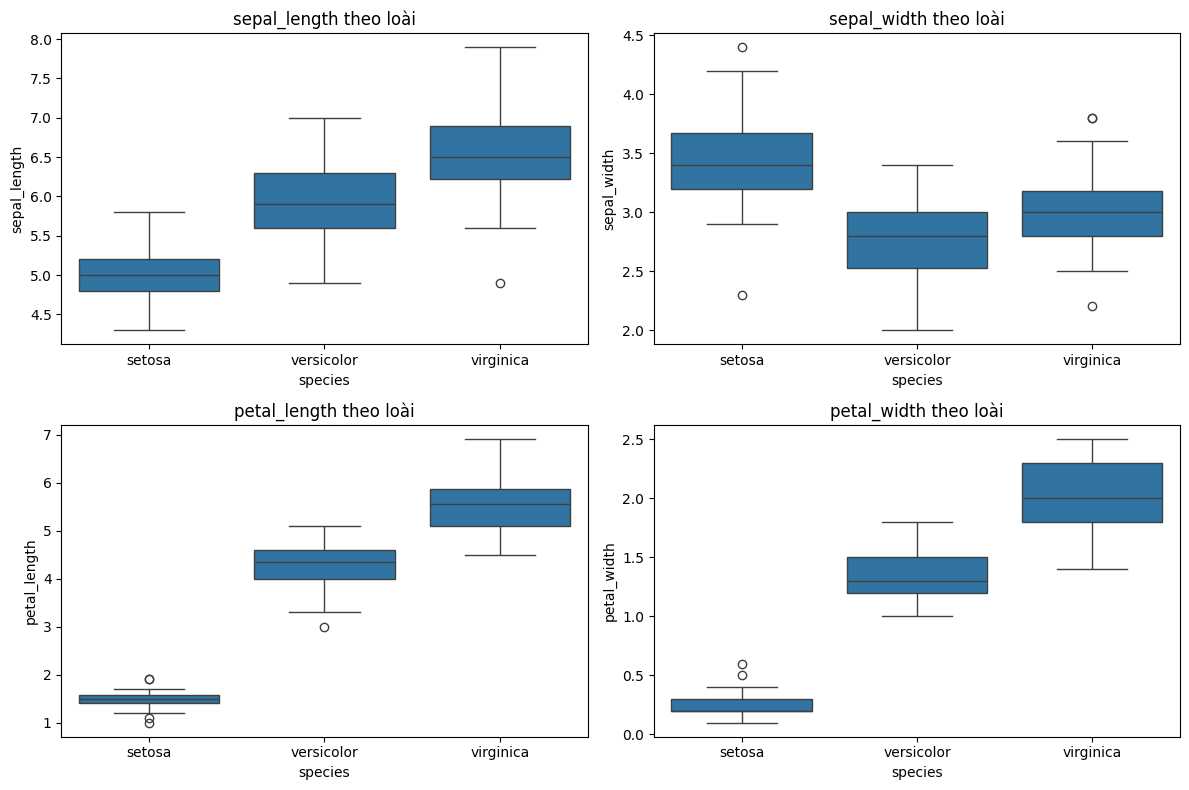

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(f"{col} theo loài")
plt.tight_layout()
plt.show()

**Nhận xét 2.2:** Với `petal_length`/`petal_width`, ba hộp **gần như không chồng nhau** (setosa nằm tách hẳn dưới cùng) → phân biệt loài rất tốt. Ngược lại `sepal_width` các hộp **chồng lấn ở 2 loài versicolor và virginica**, khó dùng một mình để tách loài. Có vài điểm outliner ở virginica và setosa.

### 2.3. Mô phỏng

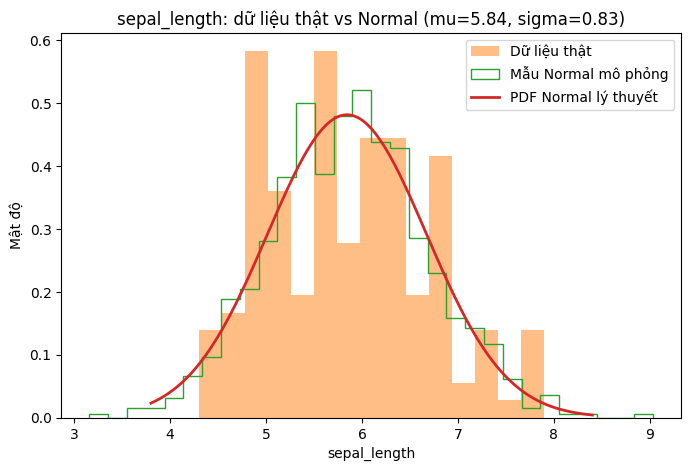

In [8]:
import numpy as np
np.random.seed(42)  # cố định để Restart & Run All ra kết quả giống nhau

col = "sepal_length"
data = df[col].values
mu, sigma = data.mean(), data.std(ddof=1)

# 1. sinh mẫu ngẫu nhiên từ Normal cùng mean, std bằng np.random.normal
sim = np.random.normal(mu, sigma, size=1000)

# 2. đường PDF Normal lý thuyết
xs = np.linspace(data.min() - 0.5, data.max() + 0.5, 200)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=15, density=True, alpha=0.5, color="tab:orange", label="Dữ liệu thật")
plt.hist(sim, bins=30, density=True, histtype="step", color="tab:green", label="Mẫu Normal mô phỏng")
plt.plot(xs, pdf, color="tab:red", linewidth=2, label="PDF Normal lý thuyết")
plt.title(f"{col}: dữ liệu thật vs Normal (mu={mu:.2f}, sigma={sigma:.2f})")
plt.xlabel(col)
plt.ylabel("Mật độ")
plt.legend()
plt.show()

**Nhận xét 2.3:** Đường PDF lý thuyết bám tương đối dạng tổng thể của `sepal_length` nhưng không khớp hoàn toàn: histogram thực tế hơi gồ ghề (nhiều đỉnh cao, thấp khác nhau). Lý do là `sepal_length` là **hỗn hợp 3 loài** (mỗi loài một trung bình khác nhau) nên tổng thể lệch khỏi Normal thuần.

## Phần 3: Phân tích đa biến & tương quan

### 3.1. Ma trận hiệp phương sai và tương quan

In [9]:
cov_matrix = df[numeric_cols].cov().round(3)
corr_matrix = df[numeric_cols].corr().round(3)
print("Ma trận hiệp phương sai (covariance):")
print(cov_matrix)
print("\nMa trận tương quan (correlation):")
print(corr_matrix)

Ma trận hiệp phương sai (covariance):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         0.686       -0.042         1.274        0.516
sepal_width         -0.042        0.190        -0.330       -0.122
petal_length         1.274       -0.330         3.116        1.296
petal_width          0.516       -0.122         1.296        0.581

Ma trận tương quan (correlation):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


**Nhận xét 3.1:** Tương quan **dương rất mạnh** giữa `petal_length` và `petal_width` (~**0.96**), giữa `petal_length` và `sepal_length` (~0.87). Riêng `sepal_width` tương quan **âm** với các biến còn lại.

- tương quan dương là cái này tăng thì cái kia cũng tăng.

- tương quan âm là cái này tăng thì cái kia giảm.

### 3.2. Heatmap tương quan

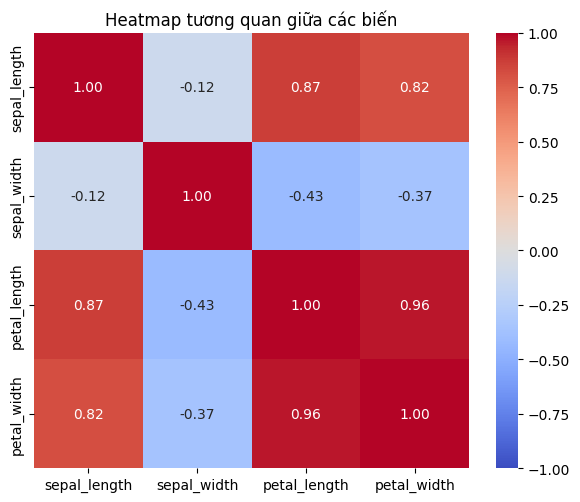

In [10]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Heatmap tương quan giữa các biến")
plt.tight_layout()
plt.show()

**Nhận xét 3.2:** Cặp mạnh nhất là **`petal_length` – `petal_width` (0.96)**: hai biến petal gần như chứa cùng thông tin, đưa cả hai vào mô hình tuyến tính sẽ dư thừa. `sepal_width` gần như độc lập với nhóm còn lại (nhận toàn giá trị âm màu xanh dương).

### 3.3. Pairplot tô màu theo loài

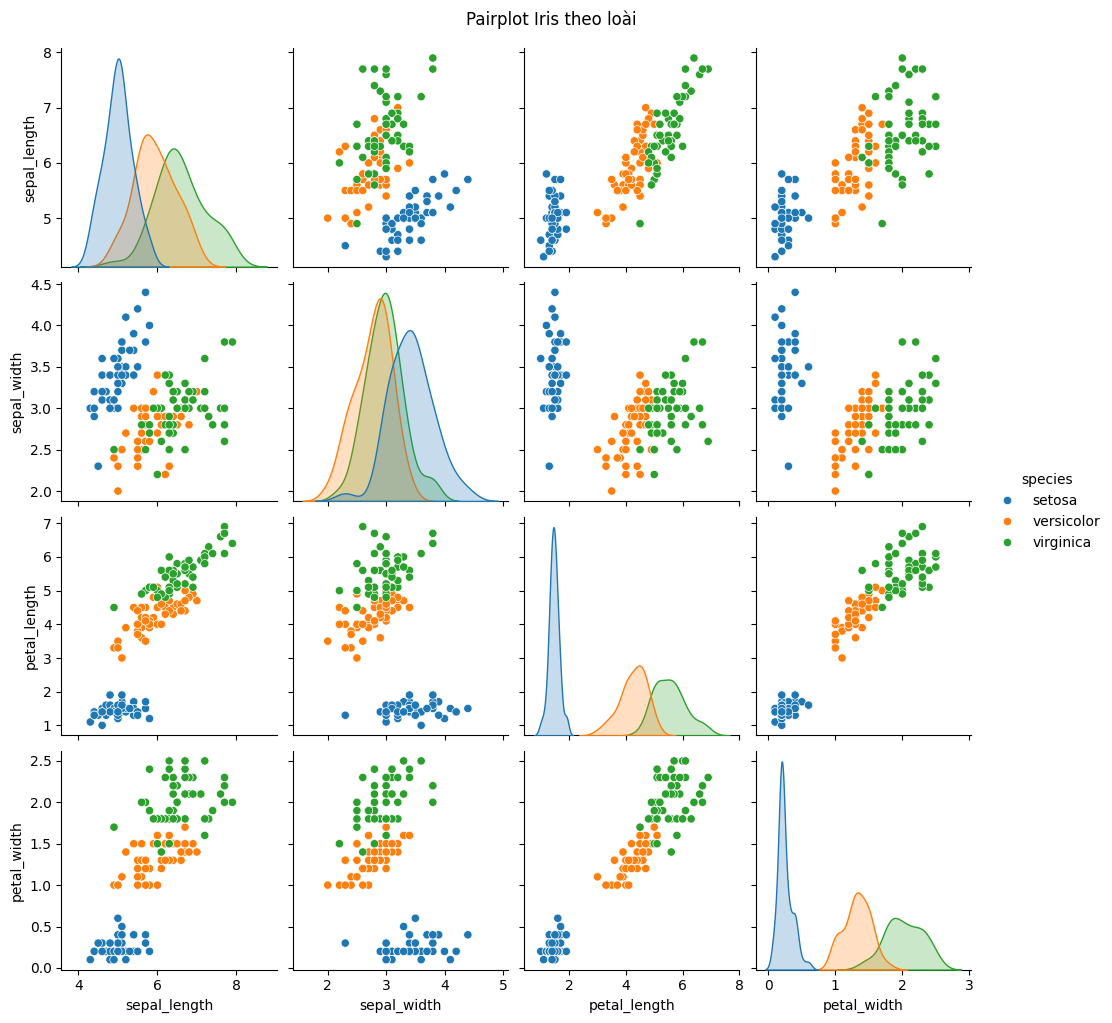

In [11]:
sns.pairplot(df, hue="species", vars=numeric_cols, diag_kind="kde")
plt.suptitle("Pairplot Iris theo loài", y=1.02)
plt.show()

**Nhận xét 3.3:** Trên hầu hết các cặp biến, **setosa** tách hoàn toàn khỏi hai loài kia, *versicolor* và *virginica* chồng lấn nhẹ nhưng vẫn phân tách khá tốt trong không gian petal. Scatter `petal_length`–`petal_width` cho thấy quan hệ **tuyến tính dương** rõ, khớp hệ số 0.96 ở trên mục 3.2.

## Phần 4 — Xác suất & Định lý Bayes

**Bài toán chẩn đoán:** một bệnh có tỉ lệ mắc `P(B) = 0.01`. Xét nghiệm có:
- Độ nhạy (true positive): `P(+|B) = 0.99`
- Dương tính giả (false positive): `P(+|¬B) = 0.05`

### 4.1. Tính xác suất hậu nghiệm P(B | +)

In [12]:
P_B = 0.01               # tỉ lệ mắc bệnh
P_pos_given_B = 0.99     # độ nhạy
P_pos_given_notB = 0.05  # dương tính giả

# xác suất xét nghiệm dương tính (toàn phần) theo công thức xác suất toàn phần
P_pos = P_pos_given_B * P_B + P_pos_given_notB * (1 - P_B)
# định lý Bayes
P_B_given_pos = P_pos_given_B * P_B / P_pos

print(f"P(dương tính)       = {P_pos:.4f}")
print(f"P(mắc bệnh | dương) = {P_B_given_pos:.4f}  (~{P_B_given_pos*100:.1f}%)")

P(dương tính)       = 0.0594
P(mắc bệnh | dương) = 0.1667  (~16.7%)


**Nhận xét 4.1:** Dù xét nghiệm rất nhạy (99%), khi có kết quả dương tính thì xác suất thực sự mắc bệnh chỉ **~16.7%** 

### 4.2. Khảo sát P(B | +) theo tỉ lệ mắc bệnh P(B)

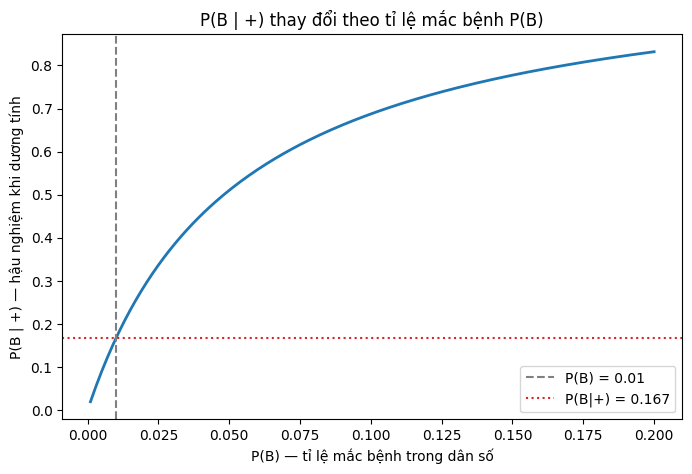

In [13]:
P_B_range = np.linspace(0.001, 0.2, 200)
P_pos_range = P_pos_given_B * P_B_range + P_pos_given_notB * (1 - P_B_range)
posterior = P_pos_given_B * P_B_range / P_pos_range

plt.figure(figsize=(8, 5))
plt.plot(P_B_range, posterior, color="tab:blue", linewidth=2)
plt.axvline(0.01, color="gray", linestyle="--", label="P(B) = 0.01")
plt.axhline(P_B_given_pos, color="tab:red", linestyle=":", label=f"P(B|+) = {P_B_given_pos:.3f}")
plt.title("P(B | +) thay đổi theo tỉ lệ mắc bệnh P(B)")
plt.xlabel("P(B) — tỉ lệ mắc bệnh trong dân số")
plt.ylabel("P(B | +) — hậu nghiệm khi dương tính")
plt.legend()
plt.show()

**Nhận xét 4.2 Khi bệnh **hiếm** (P(B) nhỏ), số người khỏe mạnh đông áp đảo nên dù dương tính giả chỉ 5% thì **số ca dương giả vẫn nhiều hơn số ca dương thật** → P(B|+) thấp. Đường cong tăng nhanh khi bệnh phổ biến hơn. 

### 4.3. (Bonus) Bộ lọc spam đơn giản theo Naive Bayes

In [14]:
# tập huấn luyện nhỏ: (nội dung email, nhãn) với 1 = spam, 0 = ham
train = [
    ("khuyen mai giam gia mua ngay", 1),
    ("trung thuong nhan tien mien phi", 1),
    ("mua ngay keo khuyen mai lon", 1),
    ("nhan qua mien phi click link", 1),
    ("hop bao cao du an ngay mai", 0),
    ("lich hoc mon may hoc tuan nay", 0),
    ("gui ban tai lieu du an", 0),
    ("hen gap ca phe cuoi tuan", 0),
]

def word_counts(docs):
    counts = {}
    for text in docs:
        for w in text.split():
            counts[w] = counts.get(w, 0) + 1
    return counts

spam_docs = [t for t, y in train if y == 1]
ham_docs = [t for t, y in train if y == 0]
vocab = sorted({w for t, _ in train for w in t.split()})

spam_wc = word_counts(spam_docs)
ham_wc = word_counts(ham_docs)
n_spam = sum(spam_wc.values())
n_ham = sum(ham_wc.values())
V = len(vocab)

prior_spam = len(spam_docs) / len(train)
prior_ham = len(ham_docs) / len(train)

def log_prob(text, wc, n_words, prior):
    # cộng log để tránh underflow; Laplace smoothing +1 để tránh xác suất 0
    lp = np.log(prior)
    for w in text.split():
        lp += np.log((wc.get(w, 0) + 1) / (n_words + V))
    return lp

def predict_spam(text):
    ls = log_prob(text, spam_wc, n_spam, prior_spam)
    lh = log_prob(text, ham_wc, n_ham, prior_ham)
    m = max(ls, lh)  # chuẩn hóa 2 log về xác suất
    ps, ph = np.exp(ls - m), np.exp(lh - m)
    return ps / (ps + ph)

tests = [
    "khuyen mai mien phi click ngay",
    "gui ban lich hop du an tuan nay",
    "trung thuong lon nhan qua ngay",
]
for t in tests:
    p = predict_spam(t)
    nhan = "SPAM" if p >= 0.5 else "HAM"
    print(f"P(spam) = {p:.3f} -> {nhan:4s} | {t}")

P(spam) = 0.993 -> SPAM | khuyen mai mien phi click ngay
P(spam) = 0.001 -> HAM  | gui ban lich hop du an tuan nay
P(spam) = 0.989 -> SPAM | trung thuong lon nhan qua ngay


**Nhận xét bonus:** Làm chạy thử nên chưa có gì nhiều, nếu cần cải thiện thì cần kiếm dataset chuẩn cho email quảng cáo bằng tiếng anh và tiếng việt rồi bắt đầu làm sạch dữ liệu và train kỹ hơn